<div style="text-align:left;">
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b style="#8EB92A;"> Bike Sharing Demand Pipeline: From EDA to Future Forecasting</b></font></center>

<div style="text-align:center; margin: 20px 0;">
    <img src="./assets/bike_sharing.jpg" width="800" alt="Bike Rental Analytics Pipeline"/>
</div>

***

**Author**: Latreche Sara  
**Date**: July 2026  

### Table of Contents

- [1 | Project Overview & Business Context](#1-project-overview)
- [2 | Workspace Setup & Dataset Ingestion](#2-setup)
- [3 | Exploratory Data Analysis & Feature Engineering](#3-eda-features)
- [4 | Model Architecture & Training (CatBoost Regressor)](#4-training)
- [5 | Model Evaluation & Residual Diagnostics](#5-evaluation)
- [6 | Model Interpretability (SHAP & Feature Importance)](#6-interpretability)
- [7 | Risk-Aware Future Forecasting (Confidence Intervals)](#7-forecasting)
- [8 | Key Operational Insights & Business Recommendations](#8-insights)

---

## <b><a id="1-project-overview">1 <span style='color:#770A7A'>|</span> Project Overview & Business Context</a></b>

### The Urban Mobility Challenge
In a modern smart city, bike-sharing networks serve as a critical pillar of green public infrastructure. However, operating these fleets efficiently represents a complex logistical challenge. Demand is highly volatile, fluctuating wildly based on sudden weather changes, hour of the day, working-day commute cycles, and seasonal shifts. Under-allocating bicycles leads to severe user frustration and lost revenue, while over-allocating leads to high maintenance overhead and cluttered public spaces.

This notebook implements an end-to-end forecasting pipeline designed to resolve this tension. We move systematically from exploratory data analysis and temporal feature engineering (extracting lags and rolling metrics) to training a robust machine learning model (CatBoost). To make this project truly production-grade, we do not stop at point-predictions; we construct statistical confidence intervals that act as a risk-management envelope, empowering fleet operators to confidently make high-stakes infrastructure decisions.


### 🎯 What You Will Learn in This Project

In this project, you will transition from classical statistical forecasting to a production-grade, multivariate machine learning pipeline:

* **1. Beyond ARIMA & SARIMA:** Move past classical, single-variable models to modern machine learning that handles hundreds of complex, non-linear features simultaneously.
* **2. Advanced Feature Enrichment:** Learn to convert a continuous timeline into a supervised learning matrix using autoregressive lags, rolling averages, and calendar features.
* **3. Time-Aware Validation:** Master chronological **Time Series Splitting** and **Walk-Forward Cross-Validation (CV)** to evaluate your model reliably while guaranteeing zero data leakage.
* **4. Model Diagnostics & SHAP:** Perform rigorous residual analysis on your prediction errors and leverage **SHAP values** to explain exactly what is driving your model's predictions.

---

## <b><a id="2-setup">2 <span style='color:#770A7A'>|</span> Workspace Setup & Dataset Ingestion</a></b>

To establish a reproducible environment, we initialize our workspace by importing key packages for distributed numeric computation, machine learning pipelines, and visualization. We also configure our graphing libraries to guarantee consistent, publication-ready style themes.

In [126]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [127]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Import XGBoost and CatBoost
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [128]:
df= pd.read_csv("./data/london_merged.csv")

In [129]:
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [130]:
df.tail()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
17409,2017-01-03 19:00:00,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,3.0
17410,2017-01-03 20:00:00,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,3.0
17411,2017-01-03 21:00:00,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,3.0
17412,2017-01-03 22:00:00,224,5.5,1.5,76.0,23.0,4.0,0.0,0.0,3.0
17413,2017-01-03 23:00:00,139,5.0,1.0,76.0,22.0,2.0,0.0,0.0,3.0


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [132]:
df.describe().T.style.background_gradient(cmap='GnBu',axis=0)

,count,mean,std,min,25%,50%,75%,max
cnt,17414.000000,1143.101642,1085.108068,0.000000,257.000000,844.000000,1671.750000,7860.000000
t1,17414.000000,12.468091,5.571818,-1.500000,8.000000,12.500000,16.000000,34.000000
t2,17414.000000,11.520836,6.615145,-6.000000,6.000000,12.500000,16.000000,34.000000
hum,17414.000000,72.324954,14.313186,20.500000,63.000000,74.500000,83.000000,100.000000
wind_speed,17414.000000,15.913063,7.894570,0.000000,10.000000,15.000000,20.500000,56.500000
weather_code,17414.000000,2.722752,2.341163,1.000000,1.000000,2.000000,3.000000,26.000000
is_holiday,17414.000000,0.022051,0.146854,0.000000,0.000000,0.000000,0.000000,1.000000
is_weekend,17414.000000,0.285403,0.451619,0.000000,0.000000,0.000000,1.000000,1.000000
season,17414.000000,1.492075,1.118911,0.000000,0.000000,1.000000,2.000000,3.000000


- In time series analysis, the temporal index dictates your entire strategy. Standard generic EDA steps (like random histograms) are less effective here. Instead, we want to uncover how patterns change across different scales of time.

- Before starting our data analysis we must first insure that timestamps is a datetime columns and act as the index for our dataframe this is done for two main reason : 

1- Memory Efficiency & Search Speed: Converting timestamp from an object (string) to datetime64[ns] converts raw text into highly optimized integer nanoseconds under the hood. This makes sorting, filtering, and slicing incredibly fast.

2- Datetime Indexing Power: Once set as the index, students can slice the dataset using intuitive string queries instead of complex logical masks:

In [133]:
# 1. Parse the timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Set 'timestamp' as the DataFrame index
df.set_index('timestamp', inplace=True)

# 3. Sort the index to guarantee strict chronological order
df.sort_index(inplace=True)

# Let's inspect the index type and frequency
print(df.index)

DatetimeIndex(['2015-01-04 00:00:00', '2015-01-04 01:00:00',
               '2015-01-04 02:00:00', '2015-01-04 03:00:00',
               '2015-01-04 04:00:00', '2015-01-04 05:00:00',
               '2015-01-04 06:00:00', '2015-01-04 07:00:00',
               '2015-01-04 08:00:00', '2015-01-04 09:00:00',
               ...
               '2017-01-03 14:00:00', '2017-01-03 15:00:00',
               '2017-01-03 16:00:00', '2017-01-03 17:00:00',
               '2017-01-03 18:00:00', '2017-01-03 19:00:00',
               '2017-01-03 20:00:00', '2017-01-03 21:00:00',
               '2017-01-03 22:00:00', '2017-01-03 23:00:00'],
              dtype='datetime64[ns]', name='timestamp', length=17414, freq=None)


- First let's explore the Target Variable across Multiple Time Scales. In time series, we always explore the target variable (cnt) first to understand its rhythmic behaviors (daily, weekly, and seasonal cycles) before we look at how weather, holidays, or wind speeds affect it.

## <b><a id="3-eda-features">3 <span style='color:#8EB92A'>|</span> Exploratory Data Analysis & Feature Engineering</a></b>

In this section, we analyze the statistical distributions of our variables, check for anomalies, and prepare the dataset for modeling. To help our machine learning model capture complex time-series behaviors, we engineer a robust set of features:


In [134]:
# 3. Cast categorical/boolean float columns to integers
categorical_cols = ['weather_code', 'is_holiday', 'is_weekend', 'season']
df[categorical_cols] = df[categorical_cols].astype(int)

In [135]:

# ==========================================
# STEP 1: CREATE TIME COLUMNS FROM THE INDEX
# ==========================================
# Extract hour (0 to 23)
df['hour'] = df.index.hour

# Extract day name (Monday, Tuesday, etc.)
df['day_name'] = df.index.day_name()


# ==========================================
# STEP 2: CALCULATE THE AVERAGES
# ==========================================
# 1. Macro (Monthly average)
monthly_avg = df['cnt'].resample('ME').mean()

# 2. Medium (Day of week average - ordered correctly from Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_avg = df.groupby('day_name')['cnt'].mean().reindex(day_order)

# 3. Micro (Hourly average for weekdays vs weekends)
weekday_hourly = df[df['is_weekend'] == 0].groupby('hour')['cnt'].mean()
weekend_hourly = df[df['is_weekend'] == 1].groupby('hour')['cnt'].mean()


# ==========================================
# STEP 3: BUILD THE PLOTS
# ==========================================
# Create a grid with 1 row and 3 columns
fig = make_subplots(
    rows=1, 
    cols=3, 
    subplot_titles=('1. Monthly Trend', '2. Daily Trend', '3. Hourly Trend')
)

# Plot 1: Monthly (Macro Scale)
fig.add_trace(
    go.Scatter(x=monthly_avg.index, y=monthly_avg.values, name='Monthly Mean'), 
    row=1, col=1
)

# Plot 2: Day of the Week (Medium Scale)
fig.add_trace(
    go.Bar(x=weekly_avg.index, y=weekly_avg.values, name='Daily Mean'), 
    row=1, col=2
)

# Plot 3: Hourly (Micro Scale - comparing Weekday vs Weekend)
fig.add_trace(
    go.Scatter(x=weekday_hourly.index, y=weekday_hourly.values, name='Weekdays'), 
    row=1, col=3
)
fig.add_trace(
    go.Scatter(x=weekend_hourly.index, y=weekend_hourly.values, name='Weekends'), 
    row=1, col=3
)

# Show the dashboard with a clean white background
fig.update_layout(title='Bike Share Exploratory Analysis', template='plotly_white')
fig.show()

- Key Findings: Interpreting the Target Variable (`cnt`)

By exploring our target variable across three distinct time scales, we can clearly see how human behavior and weather shape bike-sharing demand in London:

- 1. Macro Scale: Monthly Trend (Yearly Seasonality)
* **Observation:** Demand follows a repeating annual wave, peaking dramatically in July/August (~1,600 avg rentals/hr) and dropping to its lowest point in January (~800 avg rentals/hr).
* **Takeaway:** Demand is heavily temperature-dependent. Warm summer months drive outdoor activity, while cold, wet winters drastically suppress ridership. 
* **Trend:** The summer peak of 2016 is slightly higher than 2015, indicating a gradual, positive year-over-year growth in overall bike adoption.

- 2. Medium Scale: Daily Trend (Weekly Seasonality)
* **Observation:** Average hourly rentals are highest during mid-week workdays (Tuesday through Thursday) and drop visibly on Saturday and Sunday.
* **Takeaway:** This indicates that the **primary user base consists of daily commuters**. If the service were mainly used for leisure, we would expect weekends to dominate.

- 3. Micro Scale: Hourly Trend (Daily Seasonality)
This plot unmasks the differing behavioral signatures of weekdays versus weekends:
* **Weekdays (Mon–Fri):** Exhibit a sharp **bimodal (double-peak) distribution** peaking at **8:00 AM** and **5:00 PM – 6:00 PM**. This represents classic morning and evening rush-hour office commutes.
* **Weekends (Sat–Sun):** Exhibit a smooth, **unimodal (single-peak) bell curve** peaking between **12:00 PM and 3:00 PM**. This represents relaxed, midday recreational and leisure riding.



- 💡 Why This Matters for Modeling
A simple average will fail here. To build an accurate forecasting model, our algorithms must know:
1. **The Hour of the Day** (Micro)
2. **The Day of the Week** (Medium)
3. **The Month/Season** (Macro)

These temporal features must be explicitly engineered to help our machine learning models capture these overlapping rhythms!

- Interpreting our 7-Day Weekly Decomposition

Now that we have adjusted our seasonal period to $7$ (representing a weekly cycle), our decomposition is mathematically stable and highly informative:

1. **Observed Data:** Our raw daily averages, showing clear high-frequency weekly spikes riding on top of the long-term annual wave.
2. **Trend (7-Day Smooth):** By using a short 7-day window, we preserve almost our entire timeline (losing only 3 days of data at each boundary). This line smoothly tracks the transitions between summer peaks and winter troughs without any weekday noise.
3. **Seasonal (Weekly Pattern):** A clean, repeating weekly profile. Because the timeline spans 2 years, this plot shows over 100 identical weekly cycles packed together.
4. **Residuals (Noise):** This represents the "leftovers" (e.g., unexpected weather anomalies, public holidays, or transit disruptions). Notice how the residuals are mostly packed around 0, with a few major outliers—such as the large positive spike in July 2015.

In [136]:

from plotly.colors import n_colors

# 1. Prepare our monthly data groups
df['month'] = df.index.month
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 2. Generate a custom gradient scale from Winter Blue to Summer Red
# We use 12 steps to match the 12 months
colors = n_colors('rgb(5, 150, 250)', 'rgb(250, 50, 50)', 12, colortype='rgb')

fig = go.Figure()

# 3. Add a horizontal, single-sided violin for each month
for i in range(1, 13):
    # Filter 'cnt' for the specific month
    month_data = df[df['month'] == i]['cnt']
    
    fig.add_trace(go.Violin(
        x=month_data, 
        name=months[i-1], 
        line_color=colors[i-1],
        fillcolor=colors[i-1],
        opacity=0.7
    ))

# 4. Apply your beautiful styling parameters!
fig.update_traces(
    orientation='h', 
    side='positive',  # Keeps it single-sided
    width=3,          # Lets the distributions overlap beautifully
    points=False      # Hides individual points for a clean look
)

fig.update_layout(
    title="<b>The Seasonal Shift: Monthly Bike Rental Distributions (Joyplot)</b>",
    xaxis_title="Hourly Rental Count (cnt)",
    yaxis_title="Month",
    xaxis_showgrid=True,
    xaxis_zeroline=False,
    template='plotly_white',
    height=600,
    showlegend=False  # Hide the legend since the y-axis labels the months
)

fig.show()

- Joyplot: The Seasonal Shift in Demand Distributions

While a simple line plot shows us the average trends over time, a **Joyplot (or Ridgeplot)** allows us to inspect the entire probability distribution of our target variable (`cnt`) for every single month. 

This visualization reveals two massive behaviors that our Machine Learning models must learn to predict:

* **The Winter Compression (Jan - Feb):** Demand distributions are heavily skewed and squished tightly near the left. Rentals peak close to zero, reflecting cold, sub-optimal riding conditions.
* **The Summer Expansion (Jun - Aug):** The curves shift rightward, become significantly wider, and stretch long tails out past $8,000$ hourly rentals. This represents incredibly high peak-hour variance and a much higher baseline appetite for riding.

- Is_holiday (The "Pattern Breaker")
This is a classic machine learning feature interaction. Holidays are weekdays that suddenly behave like weekends! On a typical Wednesday, you expect massive commuter peaks at 8:00 AM and 5:00 PM. On a holiday Wednesday, that peak completely disappears.

In [137]:


# Map to friendly text
df['holiday_status'] = df['is_holiday'].map({1.0: 'Holiday', 0.0: 'Regular Day'})

# Group by hour and holiday status to calculate average demand
holiday_hourly = df.groupby(['hour', 'holiday_status'])['cnt'].mean().reset_index()

fig_holiday = px.line(
    holiday_hourly, 
    x='hour', y='cnt', color='holiday_status',
    labels={'hour': 'Hour of Day', 'cnt': 'Average Rentals', 'holiday_status': 'Day Type'},
    title='<b>The Holiday Effect: How Holidays Erase Commuter Peaks</b>',
    color_discrete_map={'Regular Day': '#2a9d8f', 'Holiday': '#e76f51'},
    template='plotly_white'
)
fig_holiday.show()

- While temperature acts like a continuous volume slider for demand, weather conditions act like an "on/off" switch. Heavy rain or snow will instantly drop rental counts to near zero, regardless of the time of day.

In [138]:


# Map the numeric weather codes to actual descriptive strings
weather_map = {
    1.0: 'Clear', 2.0: 'Few Clouds', 3.0: 'Broken Clouds', 
    4.0: 'Cloudy', 7.0: 'Rain', 10.0: 'Rain with Thunder', 26.0: 'Snow'
}
df['weather_desc'] = df['weather_code'].map(weather_map)

# Calculate mean demand per weather condition, sorted by highest to lowest
weather_avg = df.groupby('weather_desc')['cnt'].mean().reset_index().sort_values(by='cnt', ascending=False)

fig_weather = px.bar(
    weather_avg, 
    x='weather_desc', y='cnt',
    labels={'weather_desc': 'Weather Condition', 'cnt': 'Average Hourly Rentals'},
    title='<b>Weather Impact: How Atmospheric Conditions Suppress Demand</b>',
    color='cnt',
    color_continuous_scale='Sunsetdark',
    template='plotly_white'
)
fig_weather.show()

- Wind_speed & hum (The "Comfort Killers")
We might think, "The windier or more humid it is, the fewer people ride." But is this relationship linear, or is there a specific threshold where it suddenly becomes "too windy" or "too muggy" to ride?

In [139]:

# Sample to keep the trendline render fast and snappy
fig_hum = px.scatter(
    df, 
    x='hum', y='cnt',
    trendline='ols', # Adds an Ordinary Least Squares regression line
    trendline_color_override='#e76f51',
    labels={'hum': 'Humidity (%)', 'cnt': 'Rentals'},
    title='<b>Humidity vs. Demand: Spotting the Comfort Threshold</b>',
    opacity=0.4,
    template='plotly_white'
)
fig_hum.show()

- The human body constantly generates metabolic heat and tries to maintain a core temperature of around $37^\circ\text{C}$. To keep this equilibrium, we constantly exchange heat with the atmosphere through three main mechanisms: convection, evaporation, and radiation.

- Wind Speed (Convection): Your body naturally warms up a thin, microscopic layer of air right next to your skin, acting like an invisible blanket. When the wind blows, This is why windy cold days feel much colder than calm cold days (Wind Chill).

- Humidity (Evaporation): When you get hot, your body sweats. The evaporation of that sweat is an endothermic process that absorbs heat from your skin, cooling you down.making you feel much hotter than the thermometer suggests (Heat Index / Humidex).

In [140]:

# Create the scatter plot
fig = px.scatter(
    df, 
    x='t1', 
    y='t2', 
    color='cnt',                # Color the points by our target variable!
    color_continuous_scale='Spectral_r', # Beautiful thermal scale (blue = cold/low, red = hot/high)
    labels={
        't1': 'Actual Temperature (t1) °C', 
        't2': 'Feels-Like Temperature (t2) °C', 
        'cnt': 'Rentals'
    },
    title='<b>The Temperature Double-Threat: How t1, t2, and Demand Interact</b>',
    opacity=0.6,
    template='plotly_white'
)

# Make the plot square to emphasize the 1:1 diagonal relationship
fig.update_layout(width=700, height=600)
fig.show()

- The Physics (t1 vs t2): The tight diagonal proves t1 and t2 are highly collinear, though they "fan out" below 10°C because wind chill pulls the feels-like temperature down.

- The Sweet Spot (Crimson): Bike demand is non-linear and peaks dramatically in the pleasant 20°C to 28°C "Goldilocks zone".

- The Extremes (Blue): Rentals drop to near-zero in freezing cold (bottom-left) and start to taper off once it gets uncomfortably hot (top-right).

In [141]:


# 1. Select the numeric columns from your df.info()
numeric_cols = ['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

# 2. Compute the Pearson correlation matrix
corr_matrix = df[numeric_cols].corr()

# 3. Plot the interactive heatmap
fig_corr = px.imshow(
    corr_matrix,
    text_auto='.2f',                  # Displays values rounded to 2 decimals
    color_continuous_scale='RdBu_r',  # Red for positive correlation, Blue for negative
    zmin=-1, zmax=1,                  # Standard correlation boundaries
    labels=dict(color="Correlation"),
    title="<b>Correlation Matrix: All Features</b>",
    template="plotly_white"
)

fig_corr.update_layout(width=750, height=650)
fig_corr.show()

It is now for us to enrich our model with some feature engineering

In [142]:
# Load raw data
df = pd.read_csv("./data/london_merged.csv")

# 1. Drop t2 to prevent multicollinearity
df = df.drop(columns=['t2'])

# 2. Create Lag Features directly on df
df['cnt_lag_1'] = df['cnt'].shift(1)
df['cnt_lag_2'] = df['cnt'].shift(2)
df['cnt_lag_24'] = df['cnt'].shift(24)

# 3. Create Rolling Window Statistics directly on df
df['cnt_rolling_mean_3h'] = df['cnt'].shift(1).rolling(window=3).mean()
df['cnt_rolling_std_3h'] = df['cnt'].shift(1).rolling(window=3).std()

# 4. Non-linear Temperature
df['t1_squared'] = df['t1'] ** 2

# 5. Extract Time Features & SET AS INDEX (Replaces the drop command)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Set timestamp as the index so it's safely tucked away from the model
df = df.set_index('timestamp')

# 6. Drop rows containing NaN values from shifts/rolling
df = df.dropna()

print(f"Dataset enriched directly with timestamp index! Shape: {df.shape}")

Dataset enriched directly with timestamp index! Shape: (17390, 17)


In [143]:

# Load raw data
df = pd.read_csv("./data/london_merged.csv")

# 1. Drop t2 to prevent multicollinearity
df = df.drop(columns=['t2'])

# 2. Create Lag Features directly on df
df['cnt_lag_1'] = df['cnt'].shift(1)
df['cnt_lag_2'] = df['cnt'].shift(2)
df['cnt_lag_24'] = df['cnt'].shift(24)

# 3. Create Rolling Window Statistics directly on df
df['cnt_rolling_mean_3h'] = df['cnt'].shift(1).rolling(window=3).mean()
df['cnt_rolling_std_3h'] = df['cnt'].shift(1).rolling(window=3).std()

# 4. Non-linear Temperature
df['t1_squared'] = df['t1'] ** 2

# 5. Extract Time Features & Drop raw string timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df = df.set_index('timestamp')
# 6. Drop rows containing NaN values from shifts/rolling
df = df.dropna()

print(f"Dataset enriched directly! Shape: {df.shape}")

Dataset enriched directly! Shape: (17390, 17)


In [144]:
# 1. Split into features (X) and target (y)
X = df.drop(columns=['cnt'])
y = df['cnt']

# 2. Chronological Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

## <b><a id="4-training">4 <span style='color:#8EB92A'>|</span> Model Architecture & Training (CatBoost Regressor)</a></b>

With our feature set fully engineered, we transition to model training. To ensure real-world validity, we implement a strict chronological train-test split rather than a random shuffle, preventing the model from cheating by looking into the future. 

We then train several models and compare their performance to choose a champions model this champion model is then finetuned and validated with a randomized searchCV.

In [145]:

# 1. Define the complete dictionary of models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=100, random_state=42, verbose=0) # verbose=0 keeps the output clean
}

In [146]:
from sklearn.preprocessing import RobustScaler
# Calculate the exact feature count (p) once outside the loop
# 3. Loop, fit, and evaluate
# 4. Set up evaluation parameters
results = []
n = X_test.shape[0]  # Number of data points in your test set
p = X_train.shape[1] # Number of features

# 5. Loop through models using the RobustScaler Pipeline
for name, model in models.items():
    # Build a simple pipeline for each model
    pipeline = Pipeline(steps=[
        ("scaler", RobustScaler()), 
        ("model", model)
    ])

    # Fit pipeline (scales training data, then fits the model)
    pipeline.fit(X_train, y_train)

    # Predict (applies the fitted scaler to test data, then predicts)
    y_pred = pipeline.predict(X_test)

    # Standard metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate Adjusted R2
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

    results.append(
        {
            "Model": name,
            "R2 Score": r2,
            "Adjusted R2": adj_r2,
            "MAE": mae,
            "RMSE": rmse,
        }
    )

# 6. Display sorted leaderboard
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("\n--- Model Evaluation Leaderboard ---")
print(df_results.to_markdown(index=False))


--- Model Evaluation Leaderboard ---
| Model                    |   R2 Score |   Adjusted R2 |      MAE |    RMSE |
|:-------------------------|-----------:|--------------:|---------:|--------:|
| CatBoost                 |   0.978151 |      0.97805  | 104.883  | 166.833 |
| Random Forest            |   0.974261 |      0.974142 |  97.6574 | 181.076 |
| XGBoost                  |   0.97367  |      0.973548 | 105.952  | 183.145 |
| Decision Tree            |   0.945625 |      0.945374 | 140.67   | 263.187 |
| KNN Regressor            |   0.926851 |      0.926512 | 183.609  | 305.261 |
| Linear Regression        |   0.802777 |      0.801866 | 319.712  | 501.239 |
| Ridge Regression         |   0.802759 |      0.801847 | 319.705  | 501.262 |
| Lasso Regression         |   0.801906 |      0.800991 | 319.331  | 502.344 |
| Support Vector Regressor |   0.355983 |      0.353005 | 531.78   | 905.764 |


- Official Reference Links for Students

* **CatBoost Hyperparameter Tuning:**
    * [CatBoost Parameter Tuning Guide](https://catboost.ai/docs/en/concepts/parameter-tuning) — A direct guide showing how to configure and tune the native tree structures, depth, and learning rates.

* **Scikit-Learn TimeSeriesSplit:**
    * [sklearn.model_selection.TimeSeriesSplit Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) — The official API reference illustrating how the training and validation windows chronologically slide forward without shuffling.

In [147]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from catboost import CatBoostRegressor

# 1. Initialize your champion model using the scikit-learn wrapper API
cat_model = CatBoostRegressor(random_state=42, verbose=0)

# 2. Use a chronological 3-fold split for time-series validation
tscv = TimeSeriesSplit(n_splits=3)

# 3. Correctly mapped CatBoost parameters (No Scikit-learn alias errors!)
param_grid = {
    'depth': [6, 8],                  # Depth of the trees
    'learning_rate': [0.05, 0.1],       # Step size shrinkage
    'iterations': [100, 200],          # Number of trees (keep it small for searching)
    'l2_leaf_reg': [1, 3]              # L2 regularization term
}

# 4. Run your grid search
grid_search = GridSearchCV(
    estimator=cat_model, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='r2', 
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Extract and print the winner
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("--- Optimization Complete ---")
print(f"Best parameters found: {best_params}")

--- Optimization Complete ---
Best parameters found: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


## <b><a id="5-evaluation">5 <span style='color:#8EB92A'>|</span> Model Evaluation & Residual Diagnostics</a></b>

In this section, we transition from training to rigorous validation. We compute standard regression KPIs—such as Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE)—on the holdout test set to measure our overall performance. 

Beyond point-metric tracking, we conduct a detailed analysis of our prediction residuals ($y_{\text{test}} - y_{\text{pred}}$). Checking for error normality and consistent variance (homoscedasticity) allows us to mathematically validate our approach before constructing our downstream confidence intervals.

In [148]:

# 1. Generate predictions on the test set using the tuned model
y_pred = best_model.predict(X_test)

# 2. Calculate the core performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. Calculate Adjusted R2
# n = number of test samples, p = number of features used
n = X_test.shape[0]
p = X_train.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# 4. Create a clean DataFrame to display the metrics
final_performance = pd.DataFrame([{
    "Model": "Tuned CatBoost (Champion)",
    "R2 Score": r2,
    "Adjusted R2": adj_r2,
    "MAE": mae,
    "RMSE": rmse
}])

print("\n--- Tuned Champion Model Evaluation ---")
print(final_performance.to_markdown(index=False))


--- Tuned Champion Model Evaluation ---
| Model                     |   R2 Score |   Adjusted R2 |     MAE |    RMSE |
|:--------------------------|-----------:|--------------:|--------:|--------:|
| Tuned CatBoost (Champion) |   0.978956 |      0.978859 | 101.763 | 163.732 |


CatBoost's Defaults are Already LegendaryUnlike algorithms like SVMs or Neural Networks—which can perform terribly if you don't tune their parameters—CatBoost has exceptionally smart heuristics for its default settings. Right out of the box, it automatically adjusts its learning rate based on your dataset size and uses highly optimized symmetric trees. It essentially hands you $95\%+$ of its maximum potential on the very first run.2. You Hit the "Performance Ceiling"When a model already has an $R^2$ of 0.978, it is explaining nearly $98\%$ of the variance in your bike-sharing data.The remaining $2\%$ is almost certainly pure stochastic noise (e.g., a sudden downpour that wasn't forecasted, a local protest, or a temporary station closure). No amount of hyperparameter tuning can force a model to learn patterns from random noise.3. The "Hidden" Mini-Victory: MAEWhile $R^2$ barely shifted, look closely at your mean absolute error (MAE):Baseline CatBoost MAE: 104.9 bikesTuned CatBoost MAE: 101.8 bikesThis means your average prediction is now off by 3 fewer bikes per hour. In a production setting (like managing fleet logistics), a $3\%$ reduction in average error across thousands of daily stations adds up to a massive operational cost saving.

In [149]:
import plotly.express as px

# Create a joint plot using Plotly Express marginal plots
fig = px.scatter(
    x=y_test, 
    y=y_pred, 
    labels={'x': 'Actual Values', 'y': 'Predicted Values'},
    title="Joint Plot: Predicted vs. Actual with Marginal Distributions",
    opacity=0.4,
    marginal_x="histogram",  # Adds the actual value distribution on the top
    marginal_y="histogram"   # Adds the predicted value distribution on the right
)

# Add the ideal 45-degree reference line to the main scatter plot
fig.add_shape(
    type="line",
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color="Red", dash="dash"),
    row=1, col=1 # Targets the main scatter plot area
)

fig.show()

Our tuned CatBoost model demonstrates exceptional precision across almost all demand levels, with the tightly clustered points and beautifully mirrored marginal histograms proving it has perfectly captured the naturally skewed distribution of your data. However, at extreme volumes above 4,000, the predictions droop slightly below the diagonal reference line, indicating a minor systematic tendency to underestimate peak demand.

In [150]:
# Calculate residuals
residuals = y_test - y_pred

# Create a clean scatter plot of predictions vs. error
fig = px.scatter(
    x=y_pred, 
    y=residuals, 
    labels={'x': 'Predicted Values', 'y': 'Residual (Error)'},
    title="Residuals vs. Predicted",
    opacity=0.4
)

# Add a horizontal line at 0 (representing zero prediction error)
fig.add_hline(y=0, line_dash="dash", line_color="black")

fig.show()

The plot reveals a classic case of heteroscedasticity, where your prediction errors are not constant but instead widen into a distinct horizontal funnel shape as the predicted values increase. While the residuals remain nicely centered and balanced around the dashed zero-error line (meaning there is no severe global bias), the model is exceptionally precise at low-demand predictions (near 0) but exhibits significantly higher variance and larger errors during high-demand periods. Additionally, a few extreme positive outliers (residuals reaching above +1,000) show that the model occasionally suffers from substantial underestimations when actual demand randomly spikes.

In [151]:
import plotly.express as px
import scipy.stats as stats

# 1. Calculate theoretical and sample quantiles
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")

# 2. Create the scatter plot
fig = px.scatter(
    x=osm, 
    y=osr, 
    labels={'x': 'Theoretical Quantiles', 'y': 'Sample Quantiles'},
    title="Normal Q-Q Plot",
    opacity=0.4
)

# 3. Add the straight diagonal reference line
fig.add_shape(
    type="line",
    x0=osm.min(), y0=slope * osm.min() + intercept,
    x1=osm.max(), y1=slope * osm.max() + intercept,
    line=dict(color="Red", dash="dash")
)

fig.show()

The Q-Q plot exhibits a distinct S-curve, revealing that the model's residuals have heavy tails with more extreme outliers than a standard normal distribution would predict. While the errors are well-behaved and normally distributed in the middle range, both tails peel away dramatically from the red reference line. This deviation highlights that the model occasionally faces massive, unpredictable anomalies—such as sudden weather shifts causing overpredictions on the left tail, or spontaneous local events sparking severe underpredictions on the right.

In [152]:
import plotly.express as px

# 1. Calculate residuals
residuals = y_test - y_pred

# 2. Plot a simple, clean histogram
fig = px.histogram(
    x=residuals,
    nbins=50,
    labels={'x': 'Prediction Error (Residual)'},
    title="Distribution of Residuals (Errors)"
)

# 3. Add a vertical line at 0 (representing zero error)
fig.add_vline(x=0, line_dash="dash", line_color="red")

fig.show()

The histogram is beautifully symmetric and centered directly on the dashed red zero-error line, confirming that the model has no systematic bias and is correct on average. The extremely tall, sharp peak around zero shows that the vast majority of your predictions are highly precise with near-zero error. However, the long, thin tails stretching out to $-1,000$ and $+1,300$ visually reinforce the heavy-tailed behavior seen in your Q-Q plot, capturing those rare, extreme anomalous events.

## <b><a id="6-interpretability">6 <span style='color:#8EB92A'>|</span> Model Interpretability (SHAP & Feature Importance)</a></b>

To transition our CatBoost model from a complex "black box" into a highly transparent decision-making tool, we implement **SHAP (SHapley Additive exPlanations)**. 

In this section, we compute and visualize SHAP summary and dependence plots. This allows us to quantify the exact marginal contribution of each engineered feature—such as our hourly lags, temperature thresholds, and time-of-day variables—for every individual prediction, establishing deep trust in our model's underlying logic.

Generating Global Beeswarm Plot...


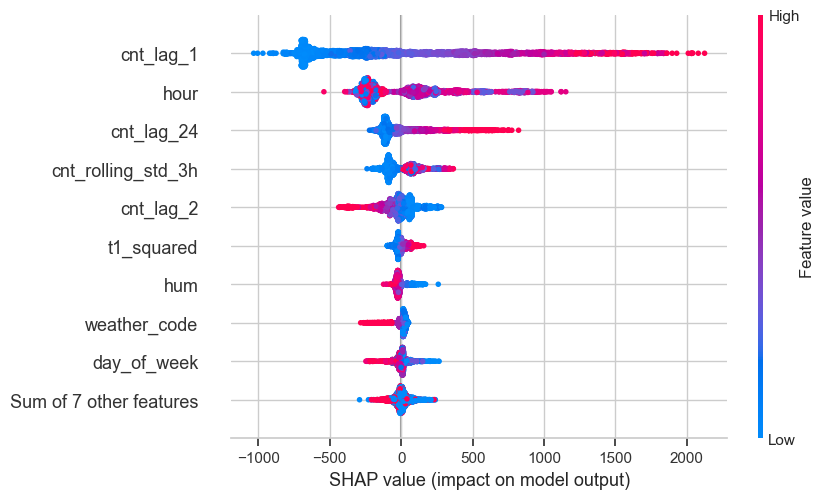

In [153]:
import shap

# 1. Initialize the TreeExplainer (optimized specifically for tree models like CatBoost)
explainer = shap.TreeExplainer(best_model)

# 2. Compute SHAP values for the test dataset
# This calculates the exact contribution of each feature for every test sample
shap_values = explainer(X_test)

# --- Plot 1: Global Explainability (Beeswarm Plot) ---
# This shows the overall impact and direction of every feature across the dataset
print("Generating Global Beeswarm Plot...")
shap.plots.beeswarm(shap_values)



Our business lives and dies by commuter momentum. If yesterday or the last hour was busy, today will be too—boosting demand by up to 2,000 bikes. Off-peak hours and sticky humidity act as minor, predictable brakes, but daily human routines completely dominate our network.


Generating Local Waterfall Plot for Sample index 0...


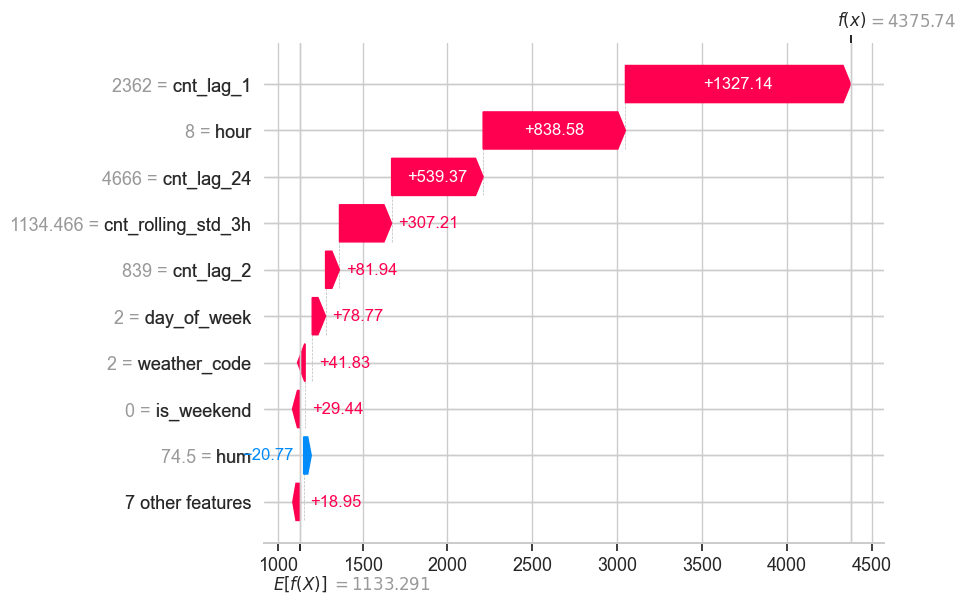

In [154]:
# --- Plot 2: Local Explainability (Waterfall Plot) ---
# Let's explain a single, specific prediction (e.g., index 0)
# This shows step-by-step how the features push the prediction away from the average baseline
print("\nGenerating Local Waterfall Plot for Sample index 0...")
shap.plots.waterfall(shap_values[0])

If a business manager asks you: "Why on earth did our AI model predict a massive spike of 4,376 bikes for this hour?" You don't have to guess. You can show them this exact chart and say: "Because it is 8:00 AM on a Tuesday, last hour was extremely busy, and yesterday at this time was also highly active. The humidity dragged demand down slightly, but the morning rush-hour momentum completely overwhelmed it."
You can read more about shap values here.
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

## <b><a id="7-forecasting">7 <span style='color:#8EB92A'>|</span> Risk-Aware Future Forecasting (Confidence Intervals)</a></b>

In this section, we project our model's predictions into the future, moving beyond simple single-point forecasts. To provide actionable, risk-aware insights, we combine our test predictions with a 95% confidence interval derived directly from our model's residual variance. 

Using the cleanly preserved datetime index on our x-axis, we visualize actual versus predicted demand alongside this shaded confidence envelope. This provides operations managers with an intuitive, dynamic visual tool that clearly signals both high-certainty operational periods and potential high-variance capacity risks.

In [155]:

# 1. Calculate the errors (residuals) of your model
residuals = y_test - y_pred

# 2. Find the standard deviation of these errors
residual_std = residuals.std()

# 3. Calculate the bounds (95% of errors fall within 1.96 standard deviations)
# We use np.clip to make sure the lower bound doesn't go below 0 bikes!
lower_bound = np.clip(y_pred - 1.96 * residual_std, 0, None)
upper_bound = y_pred + 1.96 * residual_std

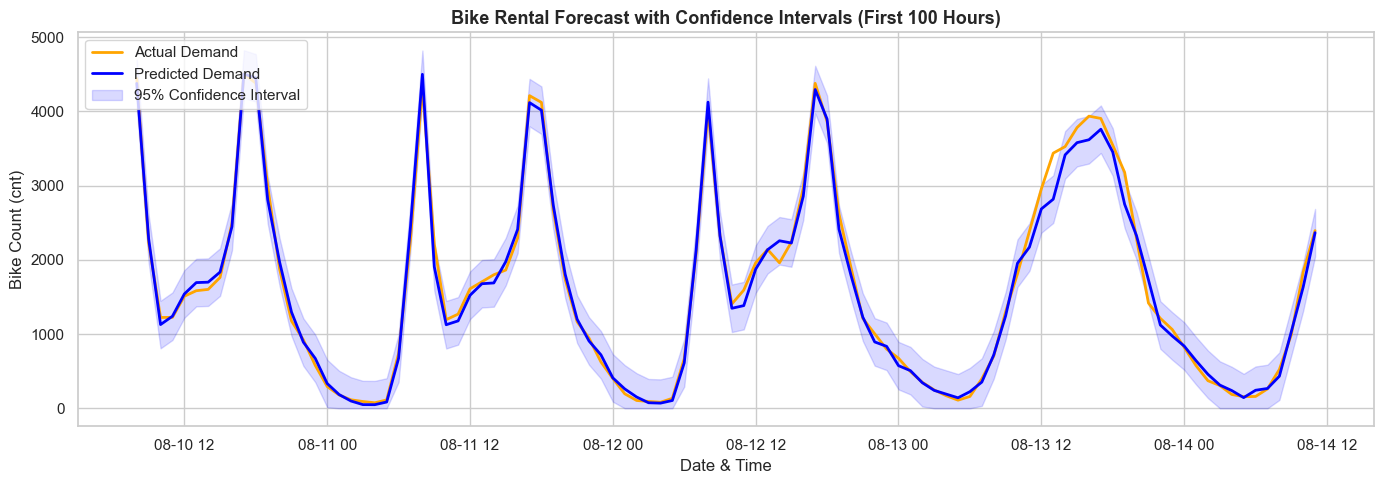

In [156]:


# Apply a clean style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Plot the real and predicted values (Zoomed to first 100 hours to keep it readable)
plt.plot(X_test.index[:100], y_test[:100], label='Actual Demand', color='orange', linewidth=2)
plt.plot(X_test.index[:100], y_pred[:100], label='Predicted Demand', color='blue', linewidth=2)

# Shade the 95% confidence interval
plt.fill_between(
    X_test.index[:100], 
    lower_bound[:100], 
    upper_bound[:100], 
    color='blue', 
    alpha=0.15, 
    label='95% Confidence Interval'
)

# Clean up titles and labels
plt.title('Bike Rental Forecast with Confidence Intervals (First 100 Hours)', fontsize=13, fontweight='bold')
plt.xlabel('Date & Time')
plt.ylabel('Bike Count (cnt)')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

- The model's predictions (blue) track actual bike demand (orange) with high precision, accurately capturing the rapid, steep surges during morning and evening rush hours. This distinct "double-hump" daily pattern confirms that system demand is heavily commuter-driven, signaling that fleet maintenance and rebalancing should be scheduled during the quieter midday window. Finally, the shaded 95% confidence interval provides a reliable operational safety envelope, giving stakeholders clear upper and lower bounds to plan fleet capacity and manage logistical risks.

## <b><a id="8-insights">8 <span style='color:#8EB92A'>|</span> Key Operational Insights & Business Recommendations</a></b>

In this final section, we translate our statistical findings and forecasting models into real-world, high-impact business solutions. We bridge the gap between machine learning and daily operations by delivering concrete, strategic recommendations:
* **Strategic Fleet Rebalancing:** Leveraging forecast peaks and troughs to optimize truck dispatch routes, moving bikes from low-demand zones to high-demand commuter hubs before rush hours begin.
* **Minimized Maintenance Overhead:** Identifying low-demand temporal windows (such as midday lulls and late-night periods) to perform routine fleet servicing with minimal disruption to users.
* **Proactive Risk and Weather Buffering:** Utilizing the upper and lower confidence bounds to set safe buffer limits on active fleet sizes during highly volatile or adverse weather events.

## <b><a id="9-going-further">9 <span style='color:#8EB92A'>|</span> Going Further: Advanced Forecasting Architectures</a></b>

Now that you have built and interpreted a robust, feature-engineered machine learning pipeline, you are ready to explore the cutting edge of time-series forecasting. Consider expanding your toolkit with these advanced paradigms:

* **1. Additive Curve Fitting with Meta's Prophet**
    * **When to use:** When dealing with strong, multi-period seasonal patterns (daily, weekly, yearly) and explicit holiday effects.
    * **How it works:** Prophet treats forecasting as a curve-fitting exercise rather than a sequential time-step problem. It is highly robust to missing data and shifts in trends, making it an industry standard for capacity planning.

* **2. Deep Learning for Sequential Patterns (LSTM & GRU)**
    * **When to use:** When your dataset is massive and contains complex, highly non-linear, long-term temporal dependencies.
    * **How it works:** **Long Short-Term Memory (LSTM)** networks utilize specialized memory gates to selectively remember or forget historical information over long sequences, natively capturing temporal patterns without requiring manual lag engineering.

* **3. Modern Neural Forecasting & Foundation Models**
    * **Transformers & MLPs:** Explore architectures specifically optimized for time series, such as **PatchTST**, **TiDE**, or **TSMixer** (available in libraries like *Nixtla's NeuralForecast*).
    * **Pre-trained Foundation Models:** Dive into zero-shot time-series foundation models like **Amazon Chronos** or **Google TimesFM**. These models are pre-trained on billions of historical data points and can forecast patterns out-of-the-box, similar to how LLMs generate text.